# Tutorial for MERFISH WMB dataset (Using label transfer to reduce running time)
Need additional packages: scanpy seaborn 

### Load the packages

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import time
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, f1_score, fowlkes_mallows_score

from Harmonics import *

import warnings
warnings.filterwarnings("ignore")

sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=30, dpi_save=500)

from matplotlib import rcParams
rcParams["figure.dpi"] = 30
rcParams["savefig.dpi"] = 500
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'
rcParams['ps.fonttype'] = 42
# rcParams['font.family'] = 'Arial'
rcParams['savefig.transparent'] = True

In [ ]:
data_dir = '../../../Data/Spatial/Transcriptomics/MERFISH_WMB_Zhang2023/animal3_sagittal/processed/'
save_dir = f'../../results/MERFISH_WMB_Zhang2023/animal3_sagittal/Harmonics/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

### Load dataset
In this tutorial, we use the label transfer mode to define niches on this large dataset. Specifically, one out of every four slices is selected for niche definition, while the remaining slices serve as targets for label transfer.

In [3]:
all_name_list = np.loadtxt(data_dir + f"slice_name_list.txt", dtype=str, delimiter=" ").tolist()

adata_list = []
slice_name_list = []
trans_list = []
trans_name_list = []

for i, slice_name in enumerate(all_name_list):

    adata = ad.read_h5ad(data_dir + slice_name + '.h5ad')

    if i % 4 == 0:
        slice_name_list.append(slice_name)
        adata_list.append(adata)
    else:
        trans_name_list.append(slice_name)
        trans_list.append(adata)

### Run Harmonics

Instantiate Harmonics

In [4]:
model = Harmonics_Model(adata_list, 
                        slice_name_list,
                        cond_list=trans_list,
                        cond_name_list=trans_name_list,
                        concat_label='slice_name',  # default
                        proportion_label=None,  # default
                        seed=1234,  # default
                        parallel=True,  # recommand to set to True for large dataset and False for small dataset
                        verbose=True,  # default
                        )

Control set comprises 6 slices, 551602 cells/spots in total.
Condition set comprises 17 slices, 1529947 cells/spots in total.


Preprocess the data (Generating the connection graph and calculating neighborhood cell type destribution for cells)

In [5]:
model.preprocess(ct_key='subclass_transfer',
                 spatial_key='spatial',  # default
                 method='joint',  # default
                 n_step=3,  # default
                 n_neighbors=20,  # default
                 cut_percentage=99,  # default
                 )

Generating Delaunay neighbor graph...


100%|██████████| 23/23 [00:24<00:00,  1.06s/it]


All done!

Performing graph completion...


100%|██████████| 23/23 [03:48<00:00,  9.94s/it]


All done!

The cell types of interest are:
ABC NN
ACB-BST-FS D1 Gaba
AD Serpinb7 Glut
ADP-MPO Trp73 Glut
AHN Onecut3 Gaba
AHN-RCH-LHA Otp Fezf1 Glut
AHN-SBPV-PVHd Pdrm12 Gaba
APN C1ql2 Glut
APN C1ql4 Glut
ARH-PVi Six6 Dopa-Gaba
ARH-PVp Tbx3 Gaba
ARH-PVp Tbx3 Glut
AV Col27a1 Glut
AVPV-MEPO-SFO Tbr1 Glut
Astro-CB NN
Astro-NT NN
Astro-OLF NN
Astro-TE NN
Astroependymal NN
B-PB Nr4a2 Glut
BAM NN
BST Tac2 Gaba
BST-MPN Six3 Nrgn Gaba
BST-SI-AAA Six3 Slc22a3 Gaba
BST-po Iigp1 Glut
Bergmann NN
CA1-ProS Glut
CA2-FC-IG Glut
CA3 Glut
CB Granule Glut
CB PLI Gly-Gaba
CBN Dmbx1 Gaba
CBN Neurod2 Pvalb Glut
CBX Golgi Gly-Gaba
CBX MLI Cdh22 Gaba
CBX MLI Megf11 Gaba
CBX Purkinje Gaba
CEA-AAA-BST Six3 Sp9 Gaba
CEA-BST Ebf1 Pdyn Gaba
CEA-BST Gal Avp Gaba
CEA-BST Rai14 Pdyn Crh Gaba
CEA-BST Six3 Cyp26b1 Gaba
CHOR NN
CLA-EPd-CTX Car3 Glut
CM-IAD-CL-PCN Sema5b Glut
COAa-PAA-MEA Barhl2 Glut
COAp Grxcr2 Glut
CS-PRNr-DR En1 Sox2 Gaba
CS-PRNr-PCG Tmem163 Otp Gaba
CS-RPO Meis2 Gaba
CT SUB Glut
CU-ECU Pax2 Gly-Gaba

100%|██████████| 23/23 [00:08<00:00,  2.80it/s]


All done!

Dataset comprises 338 cell types.

Calculating cell type distribution for microenvironments...
Microenvironments comprise 42.09 cells/spots on average. 
Minimum: 20, Maximum: 102



Perform overclustered initialization on the cell type distributions of cell neighborhoods. Resulting in *Qmax* niches. The distributions of niches are also computed.

In [6]:
model.initialize_clusters(dim_reduction=True,  # default
                          explained_var=None,  # default
                          n_components=None,  # default
                          n_components_max=100,  # default
                          standardize=True,  # default
                          method='kmeans',  # default 
                          Qmax=100, 
                          )

Performing dimension reduction...
Returning 100 principal components.

Initializing niches...
100 initial niches defined.



Perform hierarchical distribution matching to reduce the niche number to no more than *Qmin*. This step results in niche assignment under a sequence of different niche numbers (usually from *Qmax* to *Qmin*).

In [ ]:
model.hier_dist_match(assign_metric='jsd',  # default
                      weighted_merge=True,  # default
                      max_iters=100,  # default 
                      tol=1e-4,  # default 
                      test_kmeans=False,  # default
                      Qmin=2,  # default
                      )

Starting from 100 cell niches...

Assigning cells to cell niche...
Current state: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


 59%|█████▉    | 59/100 [03:37<02:31,  3.69s/it]

Distribution of cell niches (centers) converge at iteration 60.
100 cell niches left.
Merging cell niche 1 and cell niche 38...


Done!

Assigning cells to cell niche...
Current state: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


  2%|▏         | 2/100 [00:11<09:08,  5.60s/it]

...

Distribution of cell niches (centers) converge at iteration 2.
4 cell niches left.
Merging cell niche 68 and cell niche 11...
Done!

Assigning cells to cell niche...
Current state: [36, 68, 78]



  1%|          | 1/100 [00:03<05:11,  3.15s/it]

Distribution of cell niches (centers) converge at iteration 2.
3 cell niches left.
Merging cell niche 68 and cell niche 36...
Done!

Assigning cells to cell niche...
Current state: [68, 78]



  1%|          | 1/100 [00:03<05:05,  3.08s/it]

Distribution of cell niches (centers) converge at iteration 2.
2 cell niches left.
Niche count no more than 2.

Finished!



Select the 62-niche solution

In [8]:
adata_list, adata_concat = model.select_solution(n_niche=62,  # default
                                                 niche_key=f'niche_label',  # default 
                                                 auto=True,  # default
                                                 metric='jsd_v2',  # default
                                                 threshold=0.1,  # default
                                                 return_adata=True,  # default
                                                 plot=True,  # default
                                                 save=False,  # default
                                                 fig_size=(24, 6),  # default
                                                 save_dir=save_dir, 
                                                 file_name=f'score_vs_nichecount_basic_transfer.pdf',
                                                 )

Selecting solution based on specified niche count...
Done!



Transfer the niche label to other data based on the similarity between cell type distributions of niche and cell neighborhood.

In [9]:
trans_list, trans_concat = model.label_transfer(assign_metric='jsd', 
                                                niche_key='niche_label', 
                                                return_adata=True,
                                                )

Assigning cells to fixed niches...
Done!



Concatenate the data

In [10]:
adata_concat = ad.concat([adata_concat, trans_concat], label='labeltransfer', keys=['origin', 'transfered'])

In [11]:
# reorder
slice_name_list = np.loadtxt(data_dir + f"slice_name_list.txt", dtype=str, delimiter=" ").tolist()

adata_list = []
for slice_name in slice_name_list:
    adata = adata_concat[adata_concat.obs['slice_name'] == slice_name, :].copy()
    adata_list.append(adata)

adata_concat = ad.concat(adata_list, label='slice_name', keys=slice_name_list)

### Save results

In [12]:
adata_concat.write_h5ad(save_dir + f'Harmonics_labeltransfer_result_0.h5ad')

In [5]:
slice_name_list = np.loadtxt(data_dir + f"slice_name_list.txt", dtype=str, delimiter=" ").tolist()
adata_new = ad.read_h5ad(save_dir + f'Harmonics_labeltransfer_result_0.h5ad')
# adata_new = adata_concat.copy()
adata_new

AnnData object with n_obs × n_vars = 2081549 × 1122
    obs: 'donor_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'subclass_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'cell_type', 'tissue', 'development_stage', 'slice_name', 'celltype_idx', 'n_neighbors', 'niche_label', 'labeltransfer'
    obsm: 'micro_dist', 'onehot', 'spatial', 'spatial_ccf'

Load the data that contains the niche assignment defined using the whole dataset without label transfer

In [6]:
adata_new.obs['niche_label_trans'] = adata_new.obs['niche_label'].copy()
adata_tmp = ad.read_h5ad(save_dir + f'Harmonics_result_0.h5ad')
adata_new.obs['niche_label'] = adata_tmp.obs['niche_label'].copy()
del adata_tmp

### Compare the results obtained through the two modes

In [7]:
niche_colors = ['#ffff00', '#1ce6ff', '#ff34ff', '#ff4a46', '#008941', '#006fa6', '#a30059', '#ffdbe5', '#7a4900', '#0000a6',
                '#63ffac', '#b79762', '#004d43', '#8fb0ff', '#997d87', '#5a0007', '#809693', '#6a3a4c', '#1b4400', '#4fc601',
                '#3b5dff', '#4a3b53', '#ff2f80', '#61615a', '#001e09', '#6b7900', '#00c2a0', '#ffaa92', '#ff90c9', '#b903aa',
                '#d16100', '#ddefff', '#000035', '#7b4f4b', '#a1c299', '#300018', '#0aa6d8', '#013349', '#00846f', '#372101',
                '#ffb500', '#c2ffed', '#a079bf', '#cc0744', '#c0b9b2', '#c2ff99', '#ba0900', '#00489c', "#E1D656", '#6f0062', 
                '#0cbd66', '#eec3ff', '#456d75', '#b77b68', '#7a87a1', '#788d66', '#885578', '#fad09f', '#ff8a9a', '#d157a0',
                '#bec459', '#456648',]
niche_color_dict = {str(i): niche_colors[i] for i in range(len(niche_colors))}

mbr = sorted(set(adata_new.obs['major_brain_region']))
mbr_colors = ['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b', '#e377c2', '#b5bd61', '#17becf', '#aec7e8', 
              '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94']
mbr_color_dict = {mbr[i]: mbr_colors[i] for i in range(len(mbr))}

C57BL6J-3.001
FMI:  0.8120


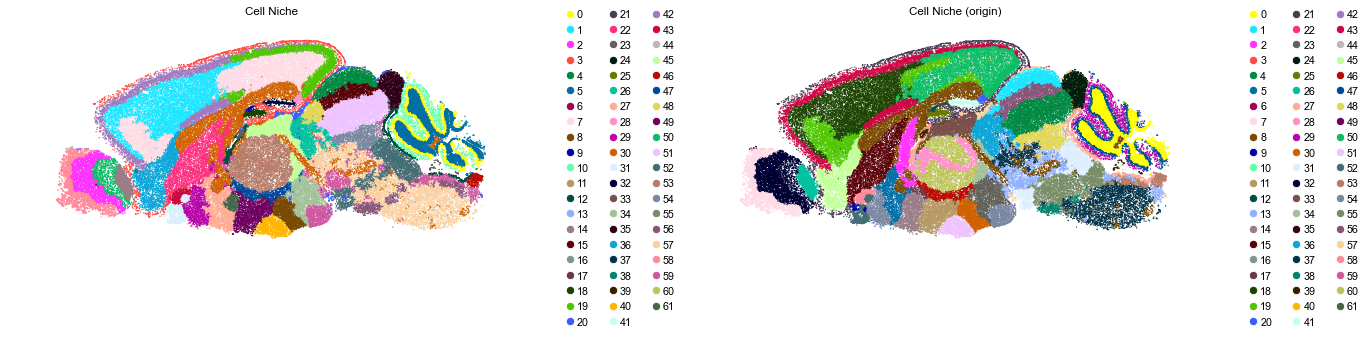

C57BL6J-3.002
FMI:  0.8804


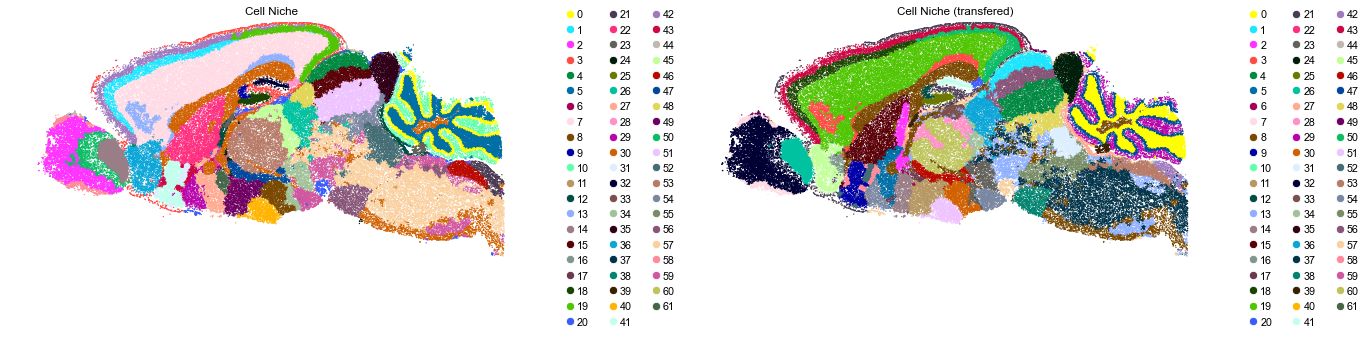

C57BL6J-3.003
FMI:  0.8975


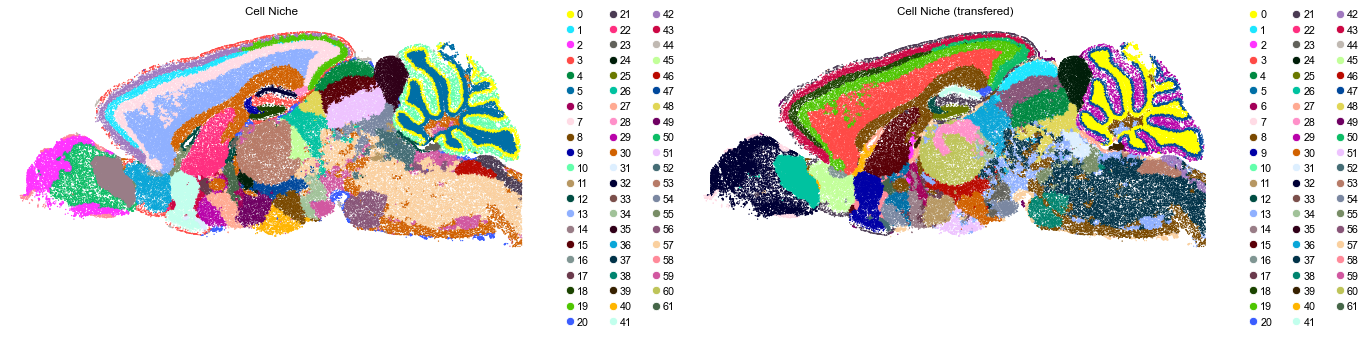

C57BL6J-3.004
FMI:  0.9253


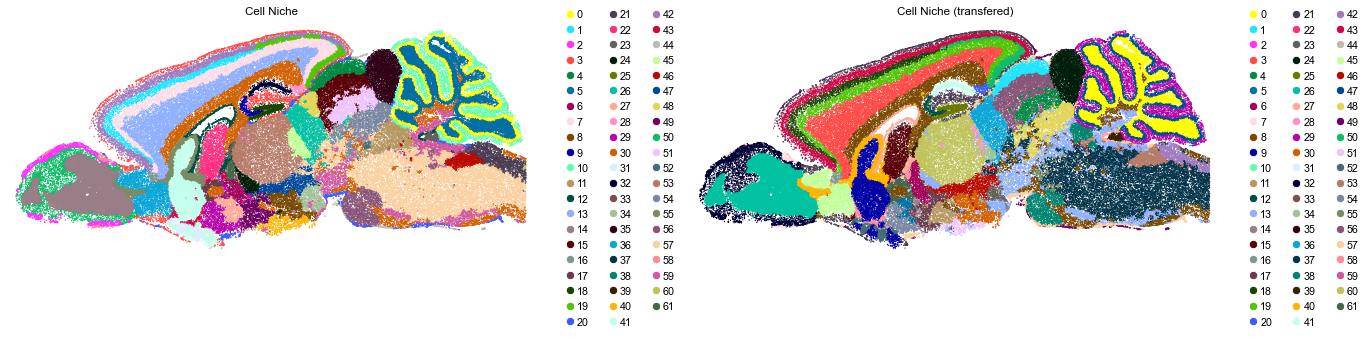

C57BL6J-3.005
FMI:  0.9501


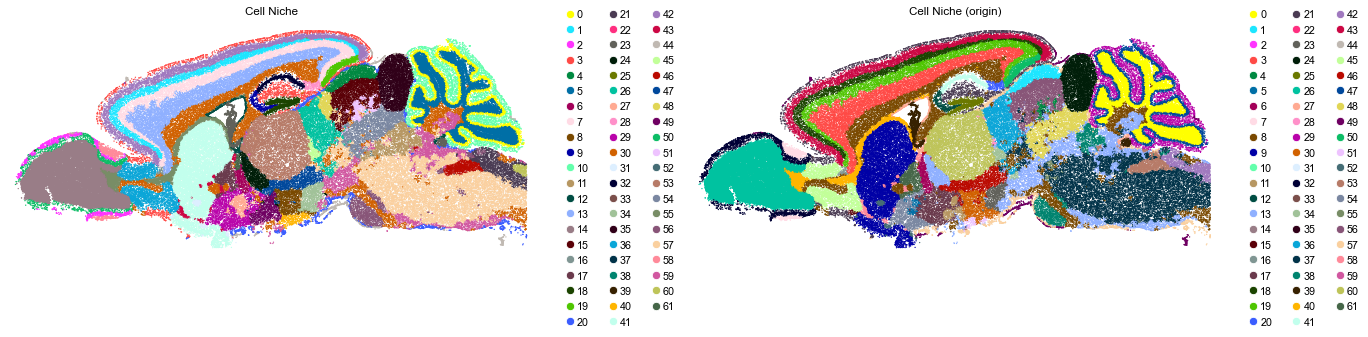

C57BL6J-3.006
FMI:  0.9132


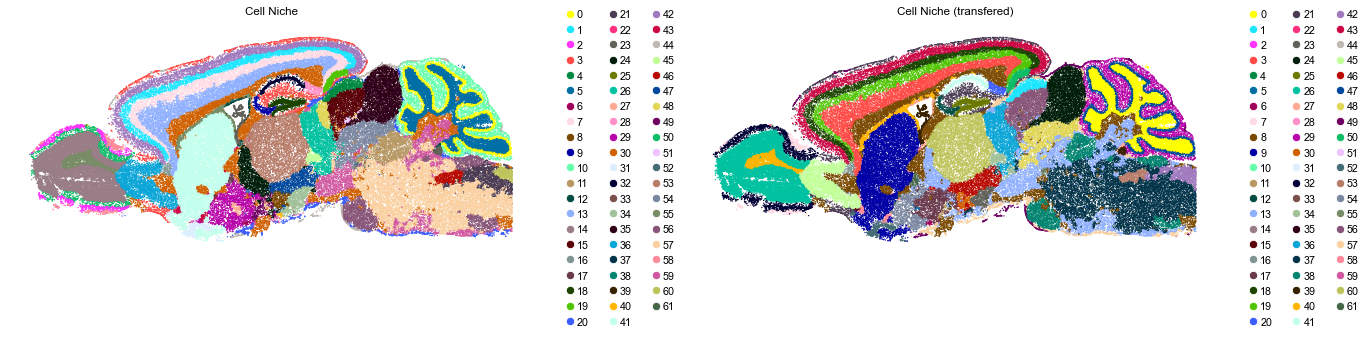

C57BL6J-3.007
FMI:  0.9201


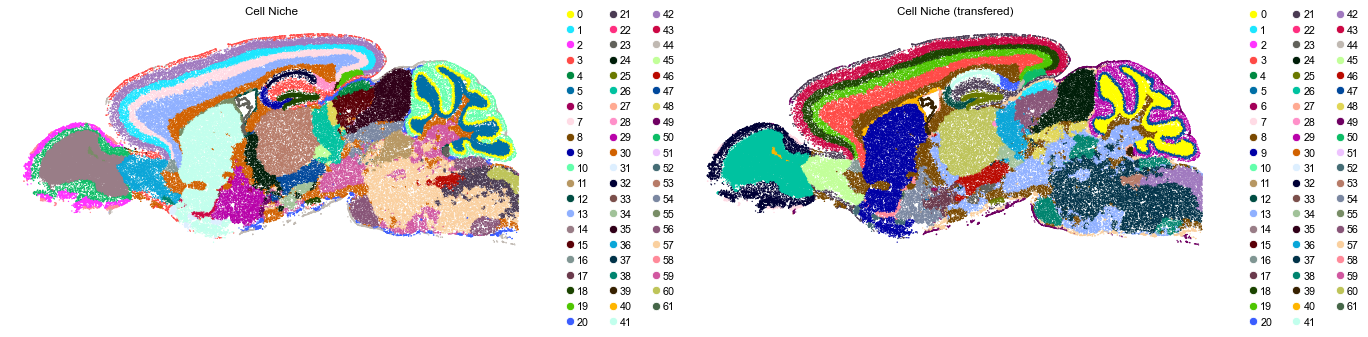

C57BL6J-3.008
FMI:  0.8810


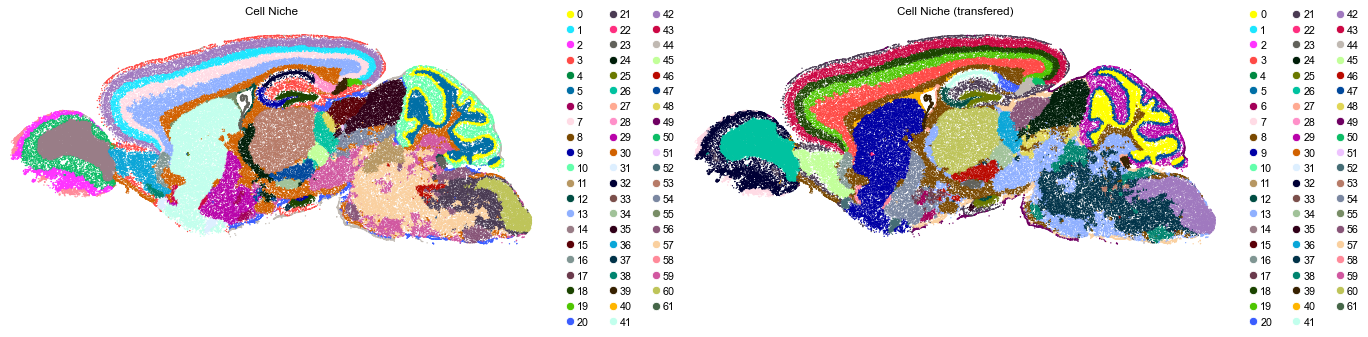

C57BL6J-3.009
FMI:  0.8911


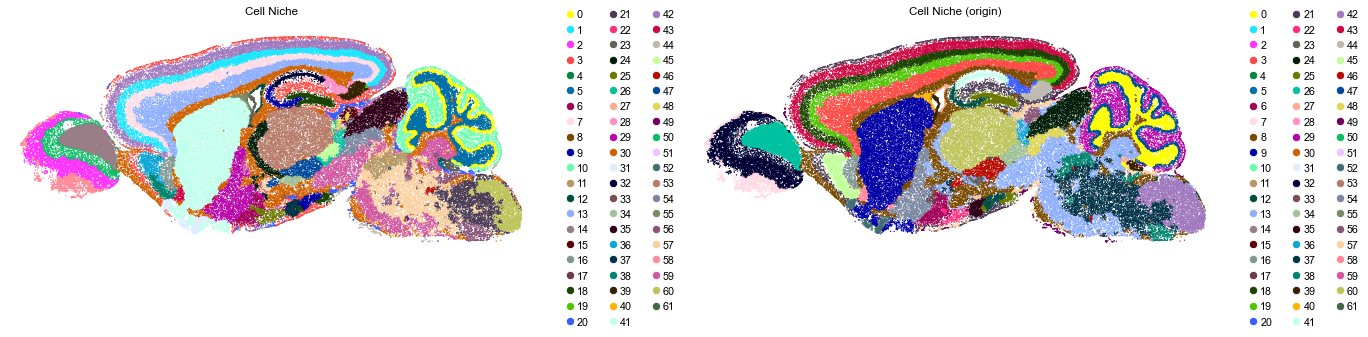

C57BL6J-3.010
FMI:  0.9004


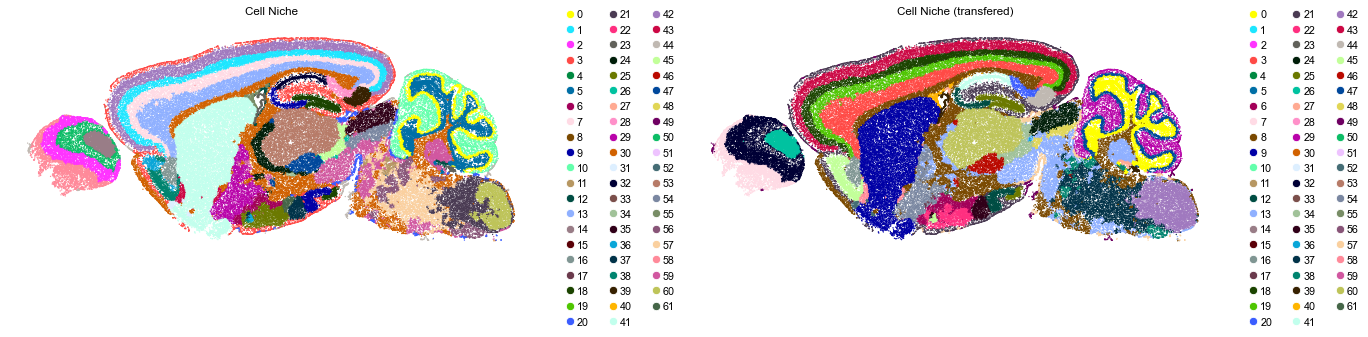

C57BL6J-3.011
FMI:  0.9434


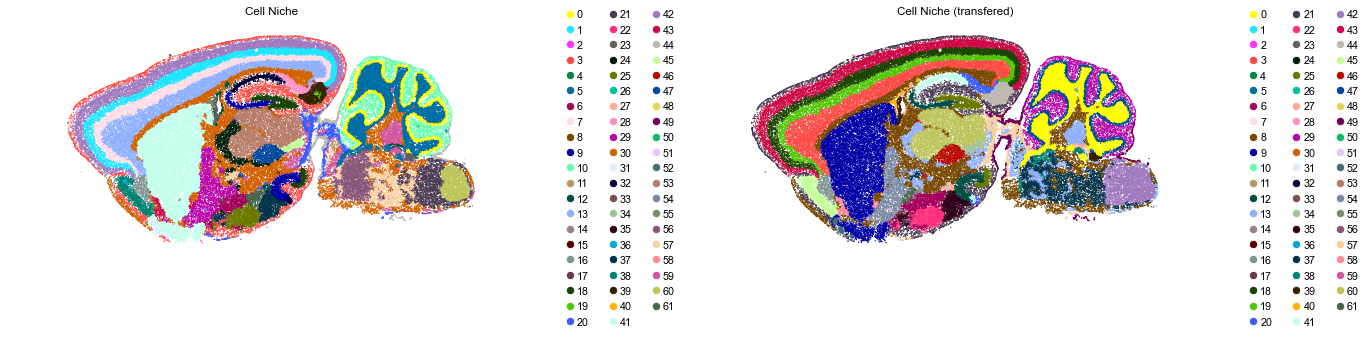

C57BL6J-3.012
FMI:  0.9597


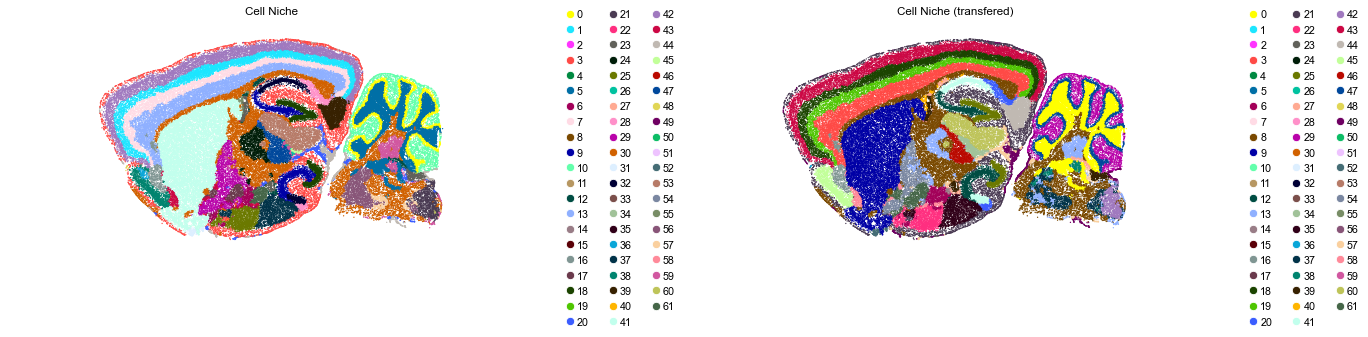

C57BL6J-3.013
FMI:  0.9680


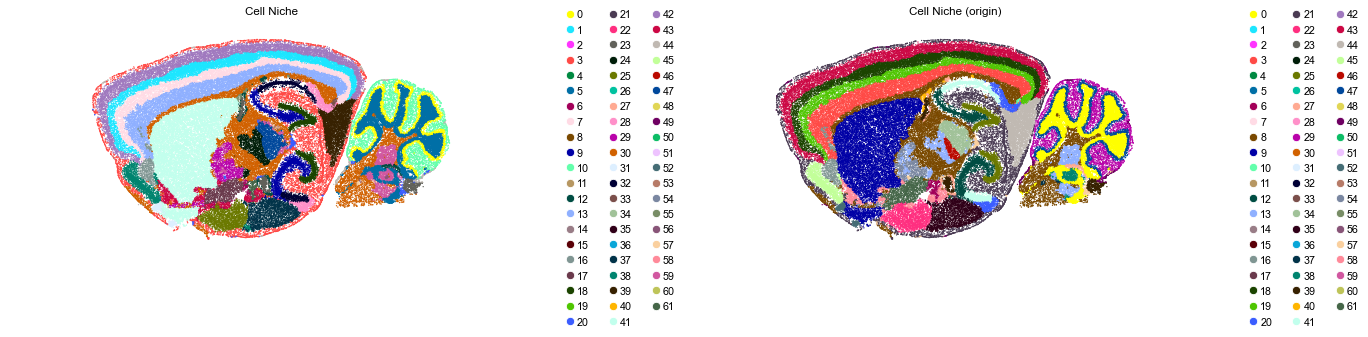

C57BL6J-3.015
FMI:  0.9791


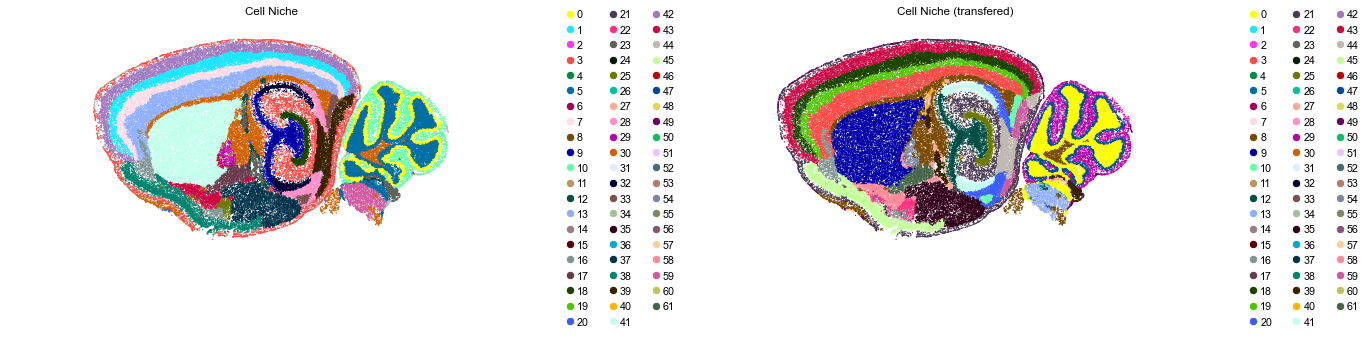

C57BL6J-3.016
FMI:  0.9662


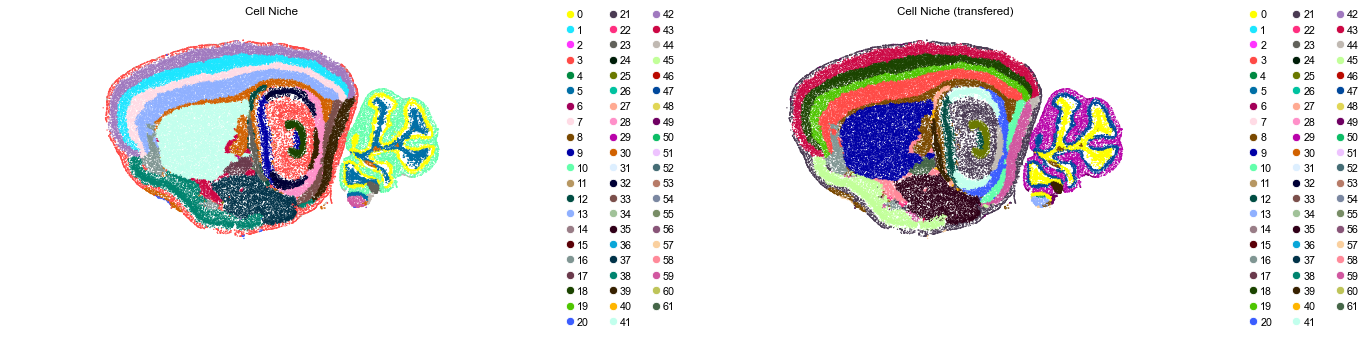

C57BL6J-3.017
FMI:  0.9680


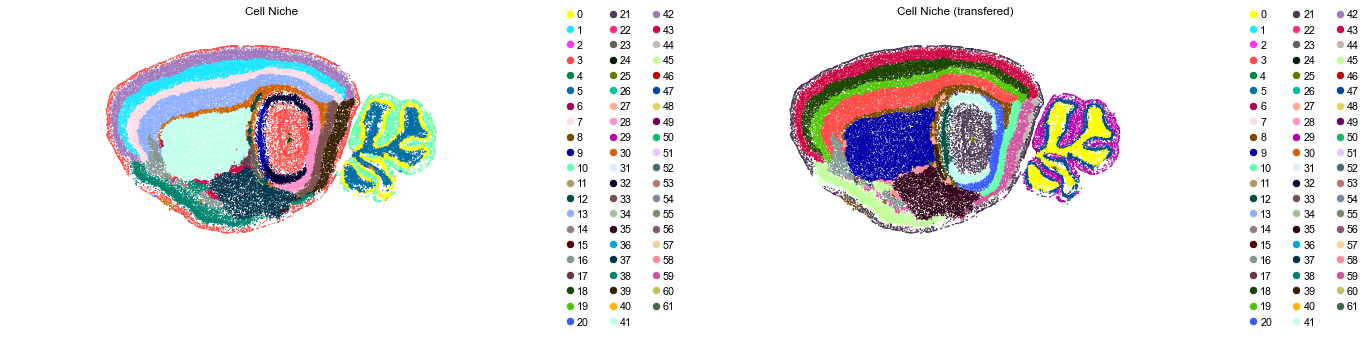

C57BL6J-3.019
FMI:  0.9613


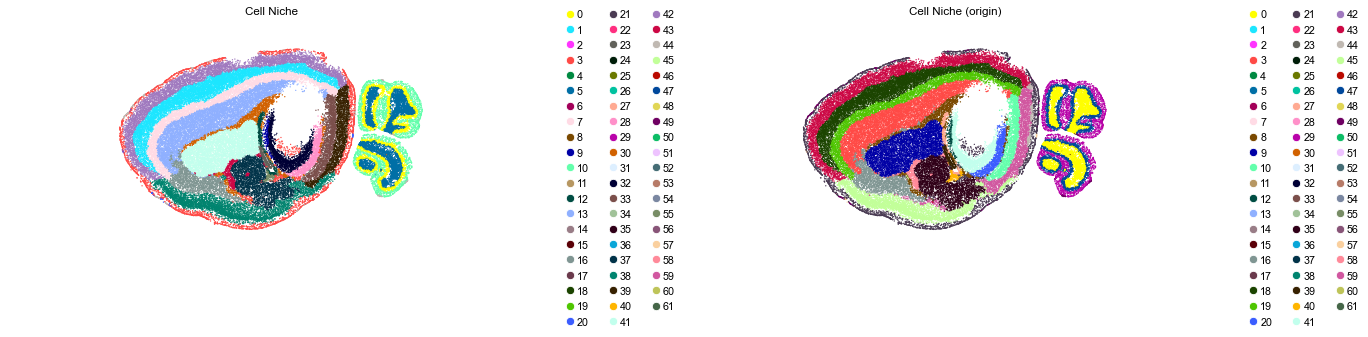

C57BL6J-3.020
FMI:  0.9586


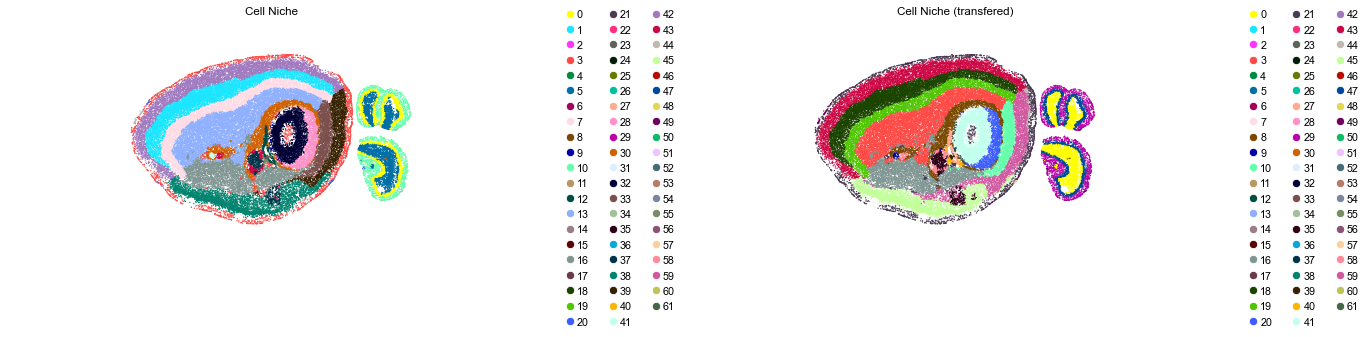

C57BL6J-3.021
FMI:  0.9537


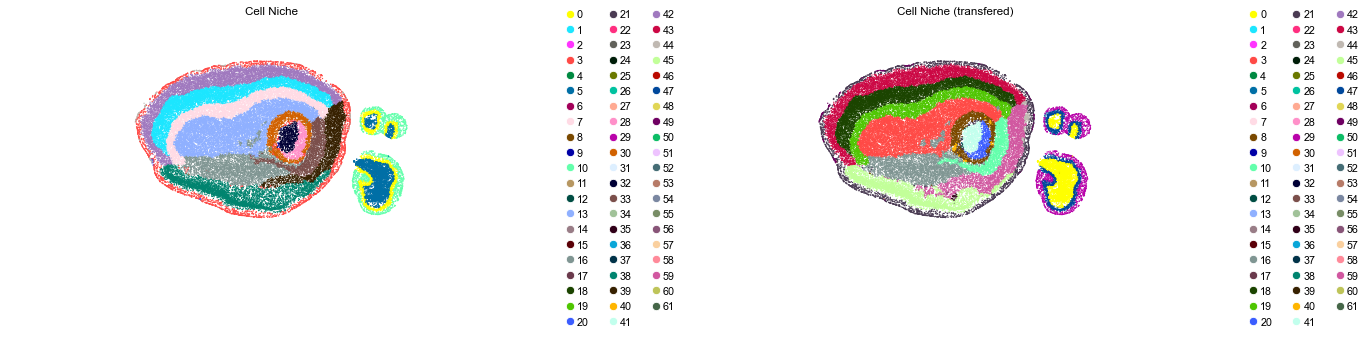

C57BL6J-3.022
FMI:  0.9057


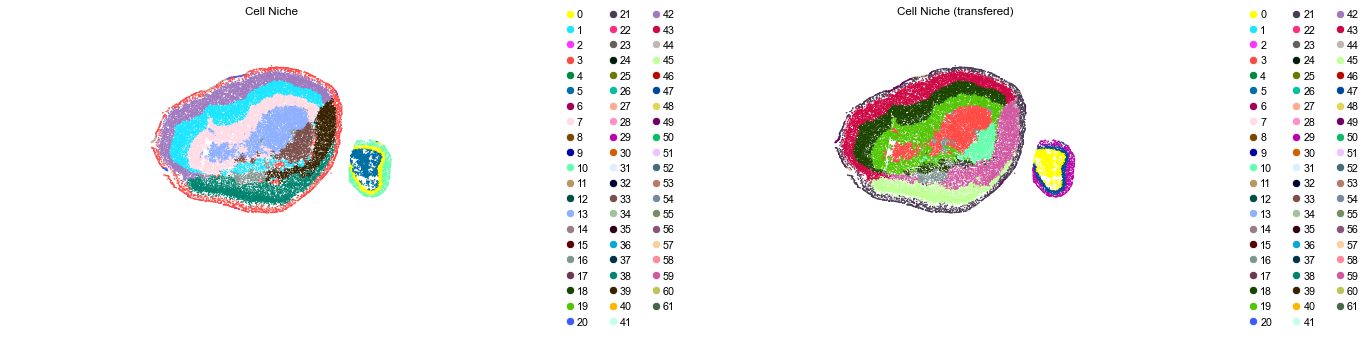

C57BL6J-3.023
FMI:  0.8996


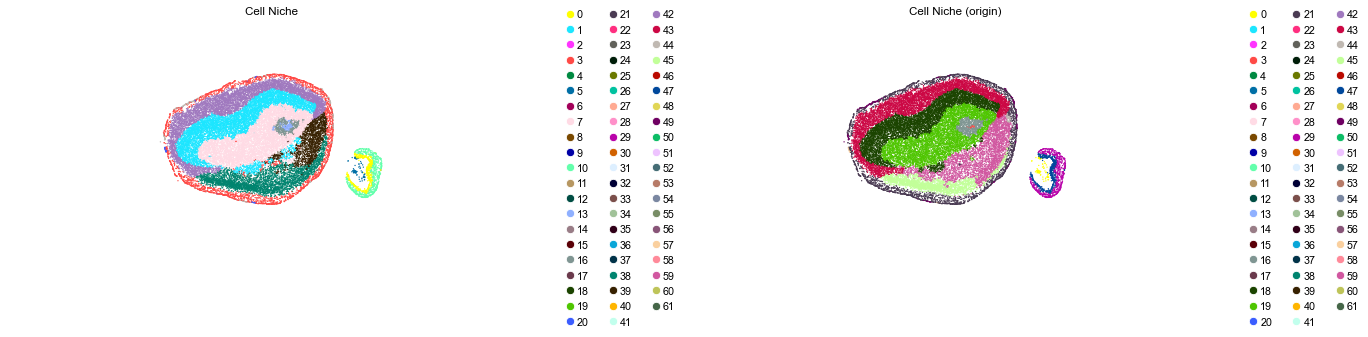

C57BL6J-3.024
FMI:  0.9295


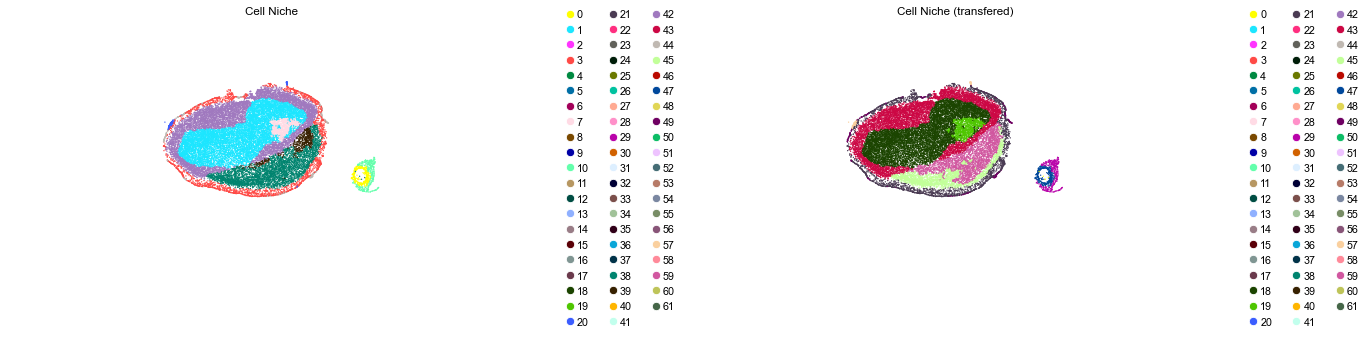

C57BL6J-3.025
FMI:  0.9857


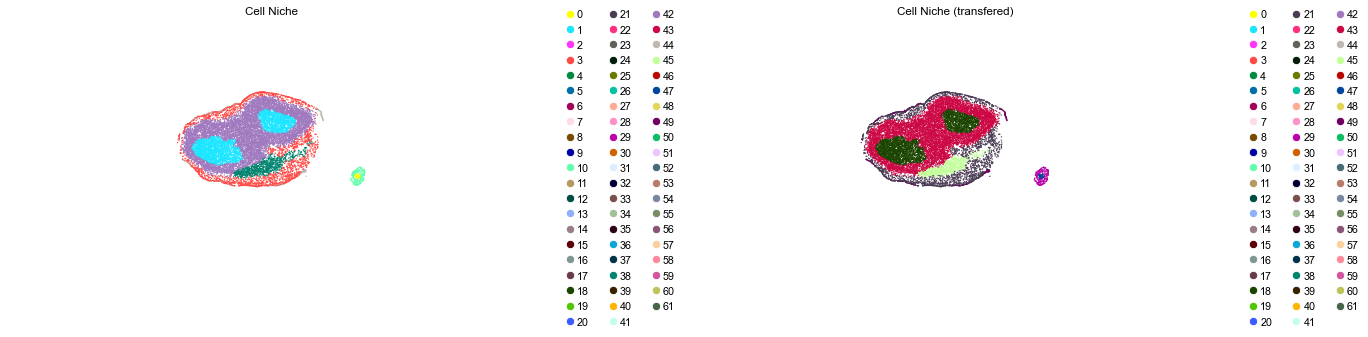

In [8]:
fmi_list = []
for i in range(len(slice_name_list)):
    
    print(slice_name_list[i])
    adata = adata_new[adata_new.obs['slice_name'] == slice_name_list[i], :].copy()
    fmi = fowlkes_mallows_score(adata.obs['niche_label'], adata.obs['niche_label_trans'])
    fmi_list.append(fmi)
    print(f"FMI: {fmi: .4f}")

    fig, axes = plt.subplots(1, 2, figsize=(23, 6))

    sc.pl.embedding(adata, basis='spatial', color='niche_label', palette=niche_color_dict,
                    ax=axes[0], s=10, show=False, frameon=False, title='Cell Niche', legend_fontsize=16)

    sc.pl.embedding(adata, basis='spatial', color='niche_label_trans', palette=niche_color_dict, 
                    ax=axes[1], s=10, show=False, frameon=False, title=f"Cell Niche ({adata.obs['labeltransfer'][0]})", legend_fontsize=16)
    
    x_mean = (max(adata.obsm['spatial'][:, 0]) + min(adata.obsm['spatial'][:, 0])) / 2
    y_mean = (max(adata.obsm['spatial'][:, 1]) + min(adata.obsm['spatial'][:, 1])) / 2
    if x_mean-7800 > min(adata.obsm['spatial'][:, 0]) or x_mean+7800 < max(adata.obsm['spatial'][:, 0]):
        raise ValueError('Please adjust the x_lim !')
    if y_mean-3600 > min(adata.obsm['spatial'][:, 1]) or y_mean+3600 < max(adata.obsm['spatial'][:, 1]):
        raise ValueError('Please adjust the y_lim !')
    for ax in axes:
        ax.set_xlim(x_mean-7800, x_mean+7800)
        ax.set_ylim(y_mean-3600, y_mean+3600)

    niche_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=label,
            markerfacecolor=color, markersize=10)
        for label, color in niche_color_dict.items()
    ]
    axes[0].legend(handles=niche_legend_elements, loc=(1.05, -0.3), frameon=False, ncol=3)
    axes[0].axis('off')

    niche_legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=label,
            markerfacecolor=color, markersize=10)
        for label, color in niche_color_dict.items()
    ]
    axes[1].legend(handles=niche_legend_elements, loc=(1.05, -0.3), frameon=False, ncol=3)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Show the FMI score for each slice by comparing the niche assignments obtained from the two modes.

Mean FMI: 0.93  Median FMI: 0.93


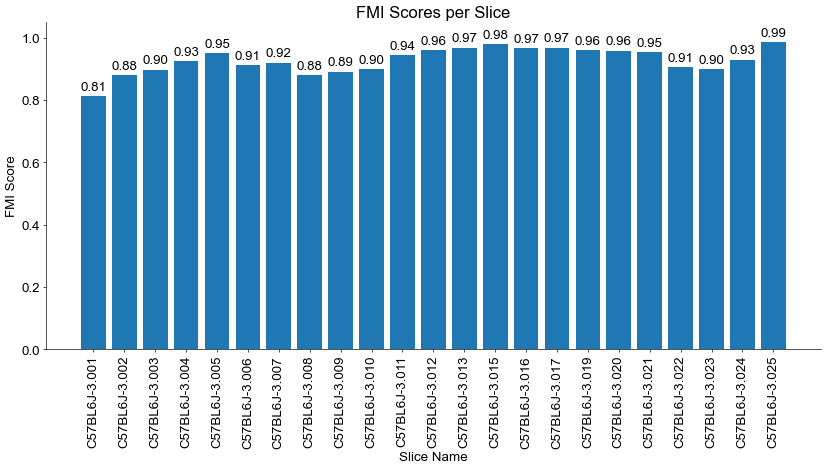

In [9]:
mean_val = np.mean(fmi_list)
median_val = np.median(fmi_list)
print(f'Mean FMI:{mean_val: .2f}  Median FMI:{median_val: .2f}')

plt.figure(figsize=(14, 8))

bars = plt.bar(slice_name_list, fmi_list)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=16)

plt.ylabel('FMI Score', fontsize=16)
plt.xlabel('Slice Name', fontsize=16)
plt.title('FMI Scores per Slice', fontsize=20)
plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(False)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()